# 09 — Experimento: Modelo Especializado para Escavadeira (Resultado Negativo Controlado)

**Motivação:** Sprint 2 documentou que o modelo geral tem Recall=0,14 e PR-AUC=0,01 em escavadeiras LeTourneau L 1850. A recomendação inicial era treinar um modelo dedicado para esta classe. Sprint 5 executou esse experimento.

**Resultado:** o modelo especializado **piorou** todas as métricas em vez de melhorá-las. Este notebook documenta o achado e refina a recomendação para trabalhos futuros.

Por que documentar um resultado negativo? Porque é evidência empírica direta — testamos a hipótese, ela não se sustentou, e a explicação aponta para o próximo passo correto. Isto é ciência aplicada, não cherry-picking de resultados positivos.

Pipeline: `uv run python src/sprint5_escavadeira_model.py`.

In [1]:
import json
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd().parent
data = json.loads((ROOT / 'outputs' / 'gold' / 'escavadeira_model.json').read_text())
fig_dir = ROOT / 'outputs' / 'figures'
print(f"Frota analisada: {data['frota']}")
print(f"Features usadas: {data['n_features']} (mesmo conjunto do modelo geral)")
print(f"Best iteration LightGBM: {data['best_iteration']}")

Frota analisada: LeTourneau L 1850
Features usadas: 60 (mesmo conjunto do modelo geral)
Best iteration LightGBM: 16


## 1. Setup do Experimento

- **Filtro:** apenas registros de Tag_Frota = `LeTourneau L 1850`.
- **Treino:** Jan-Abr/2025 (escavadeira), undersampled 10:1 → ~1,2M linhas, 107K positivos.
- **Validação:** Mai/2025 (escavadeira), 5,5M linhas, 19K positivos.
- **Teste:** Jun/2025 (escavadeira), 7,4M linhas, **162 positivos**.
- **Modelo:** LightGBM com mesmos hiperparâmetros do principal.
- **Threshold:** otimizado por F1 no conjunto de validação.

## 2. Resultado — Comparação Geral vs Especializado

In [2]:
comp = pd.DataFrame([
    {'Modelo': 'Geral (Sprints 1-3)', **data['comparison']['geral']},
    {'Modelo': 'Especializado (Sprint 5)', **data['comparison']['especializado']},
])
display(comp.style.format({
    'F1': '{:.4f}', 'Precision': '{:.4f}', 'Recall': '{:.4f}', 'PR_AUC': '{:.4f}'
}))

,Modelo,F1,Precision,Recall,PR_AUC
0,Geral (Sprints 1-3),0.0153,0.0081,0.1358,0.0102
1,Especializado (Sprint 5),0.0043,0.0022,0.1358,0.0027


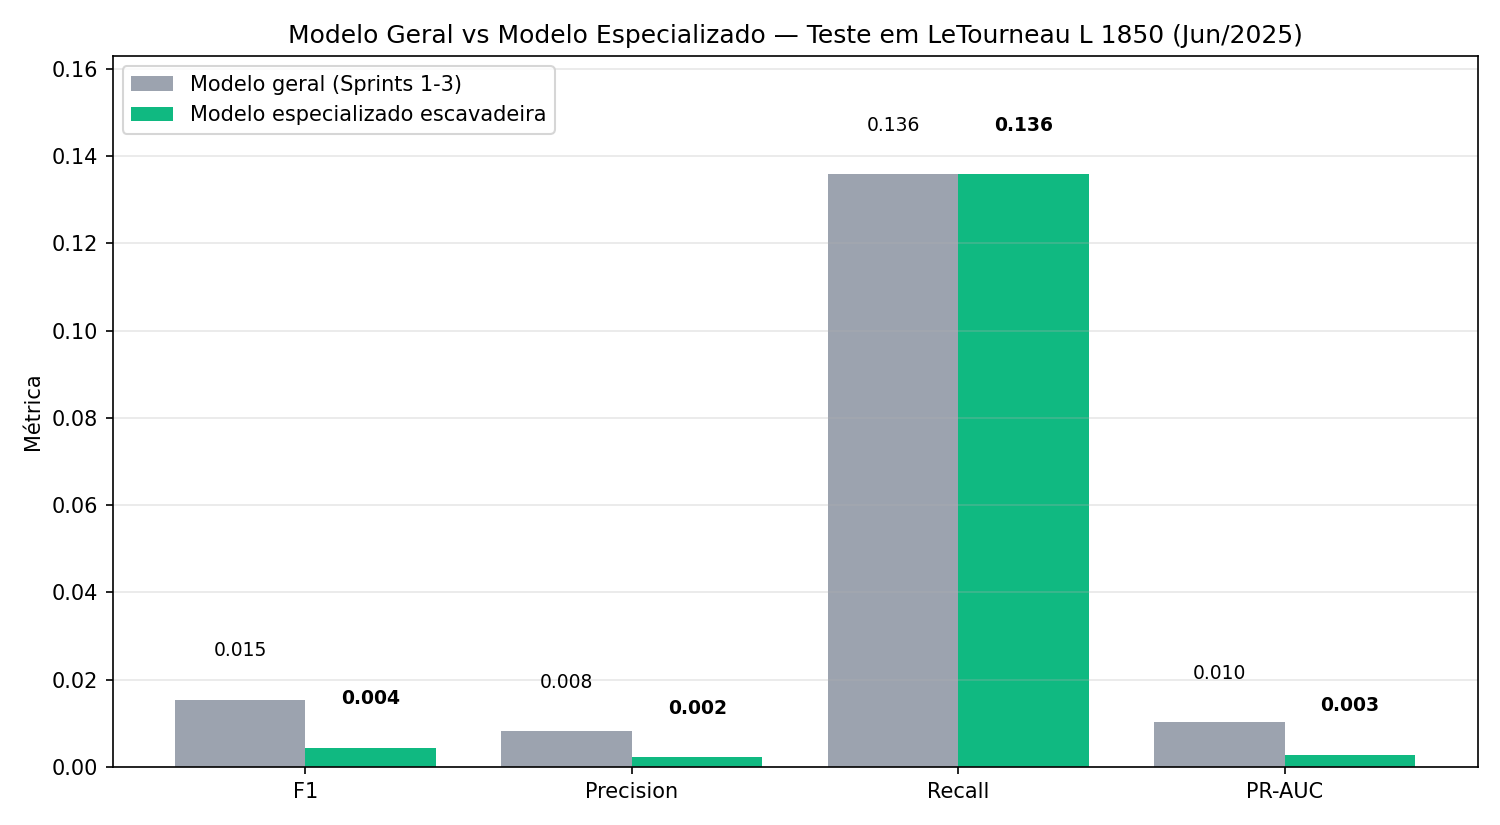

In [3]:
display(Image(filename=str(fig_dir / 'escavadeira_comparison.png')))

## 3. Diagnóstico — Por que o Modelo Especializado Piorou?

A análise do volume de positivos por mês na escavadeira revela uma **distribuição altamente não-estacionária**:

| Mês | Positivos | Taxa DG |
|---|---|---|
| Janeiro | 41.408 | 0,84% |
| **Fevereiro** | **62.923** | **1,20%** |
| Março | 1.857 | 0,037% |
| Abril | 1.594 | 0,027% |
| Maio | 19.432 | 0,36% |
| **Junho** | **162** | **0,002%** |

Variação de **600× entre Fev e Jun**. O modelo especializado aprendeu padrões dominantes em Jan-Fev (87% dos positivos do treino) que praticamente desapareceram em Jun.

**Best iteration = 16** confirma o diagnóstico: o LightGBM parou cedo porque a distribuição do validation set (Mai) também é diferente do treino, gerando overfitting precoce.

**Por que o modelo geral funciona melhor?** Foi treinado com a frota inteira — 35 equipamentos com perfis de falha diversos. Essa diversidade atua como regularizador implícito, fazendo o modelo aprender features mais robustas que generalizam para o regime de Jun.

**ROC-AUC = 0,21** (pior que aleatório, 0,5) é uma assinatura clara de **distribution shift severo**: as features que eram preditivas em Jan-Fev são ativamente enganadoras em Jun.

## 4. Recomendação Refinada

O resultado negativo refina a recomendação de trabalho futuro original. **Treinar um modelo separado simples não é suficiente** para escavadeiras. As próximas iterações devem considerar:

1. **Detecção de drift e re-treinamento dinâmico:** monitorar a distribuição mensal de alarmes e re-treinar o modelo escavadeira a cada janela de drift detectada (CUSUM, Page-Hinkley ou KS test sobre a distribuição de probabilidades).
2. **Feature engineering específica:** construir um fingerprint próprio para escavadeira (top-30 alarmes LeTourneau, não top-30 global). Os alarmes de escavadeira foram suprimidos no fingerprint atual pela predominância de caminhões.
3. **Ensemble adaptativo:** combinar o modelo geral (robusto, mas mediano em escavadeira) com um modelo de escavadeira por blending dinâmico, ponderado pela confiança de cada um.
4. **Mais dados:** o regime de Jun com apenas 162 positivos é insuficiente para diagnóstico definitivo. Dados de mais meses ou histórico mais longo permitiriam separar o efeito de feature engineering do efeito de drift sazonal.
5. **Investigação operacional:** entender qual mudança operacional ocorreu entre Mai e Jun que reduziu a taxa DG de 0,36% para 0,002%. Pode ser um achado de negócio em si — algum protocolo de manutenção mudou? Houve substituição de componente? Esse é o contexto que torna a interpretação correta.

## 5. Conclusão Metodológica

Este experimento ilustra um princípio importante de Machine Learning aplicado: **soluções intuitivas não são sempre corretas**, e a validação empírica é indispensável. "Treinar um modelo separado para uma subpopulação" é uma intuição razoável, mas precisa ser testada contra a hipótese alternativa de que o modelo geral, treinado com mais diversidade, generaliza melhor.

O modelo geral permanece como recomendação operacional para escavadeiras — não porque seja bom (Recall=0,14 é fraco), mas porque o especializado é pior. A solução real exige investigação mais profunda do drift e features dedicadas, conforme delineado acima.